# Flexible inference with `condition_on`

ProbPipe's central operation is `condition_on(model, data)`. The same function call works whether the inference engine underneath is NUTS, RWMH, neural posterior estimation, neural likelihood estimation + MCMC, or sequential Monte Carlo ABC. The model type and the inference registry decide what runs — you don't rewrite the model when you swap engines.

This tutorial makes that point concrete on a small ecology problem. We use the **Ricker population model**, a discrete-time density-dependent growth model classic in fisheries and population biology. With deterministic dynamics the likelihood is tractable and NUTS works fine. Flip on process noise and the likelihood becomes intractable, but **the same class** serves both regimes — and switching inference engines is a matter of which model wrapper you use.

The engines we'll exercise via `condition_on`:

- NUTS (for the deterministic case, via `SimpleModel`)
- `sbi_learn_conditional` (NPE) — amortized direct posterior sampling
- `sbi_learn_likelihood` (NLE) — emulated likelihood that any MCMC backend can drive
- SMC-ABC via the inference registry

> **Prerequisites:** [Getting Started tutorial](getting_started.ipynb). SBI features require `pip install probpipe[sbi]`.

In [1]:
import warnings; warnings.simplefilter('ignore')

import io
from contextlib import contextmanager, redirect_stderr, redirect_stdout

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
plt.rcParams['mathtext.default'] = 'regular'

from probpipe import (
    SimpleModel, SimpleGenerativeModel,
    condition_on, sbi_learn_conditional, sbi_learn_likelihood,
)
from probpipe.modeling import Likelihood, GenerativeLikelihood
from probpipe.distributions.multivariate import MultivariateNormal


@contextmanager
def silence():
    """Suppress stdout/stderr chatter (tqdm bars, training logs)."""
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        yield

## 1. The Ricker population model

The Ricker map is a discrete-time density-dependent growth model with optional Gaussian process noise on the log-growth rate:

$$N_{t+1} = N_t \exp\!\left(r \left(1 - \frac{N_t}{K}\right) + \epsilon_t\right), \qquad \epsilon_t \sim \mathcal{N}(0, \sigma_p^2).$$

Observed counts are Poisson with rate $\phi N_t$:

$$y_t \mid N_t \sim \text{Poisson}(\phi N_t), \qquad t = 1, \ldots, T.$$

We infer $(r, K, \phi)$ in log-space — $\theta = (\log r, \log K, \log \phi)$ — so the prior is a plain multivariate normal and all parameters stay positive after exponentiating. The noise scale $\sigma_p$ is a known setting of the model: $\sigma_p = 0$ gives the deterministic Ricker (closed-form likelihood), and any $\sigma_p > 0$ gives the stochastic Ricker (intractable likelihood). We defer the stochastic case to §5.

In [2]:
T = 40       # length of the observed time series
N0 = 5.0     # initial population size (assumed known)


class RickerObservationModel(Likelihood, GenerativeLikelihood):
    """Ricker population model with Poisson observations.

    Inheriting from both protocols makes it explicit that this class
    supplies the two APIs ProbPipe needs: ``log_likelihood`` (used by
    MCMC on a ``SimpleModel``) and ``generate_data`` (used by SBI on a
    ``SimpleGenerativeModel``).

    The ``sigma_p`` argument turns on Gaussian process noise on the
    log-growth rate.  For ``sigma_p == 0`` the trajectory is
    deterministic and ``log_likelihood`` is the exact Poisson log-pmf;
    for ``sigma_p > 0`` the latent ``N_t`` sequence is stochastic and
    the closed-form likelihood is no longer valid — ``log_likelihood``
    asserts on misuse, and only ``generate_data`` remains available.
    """

    def __init__(self, T, N0, sigma_p=0.0):
        self.T, self.N0, self.sigma_p = T, N0, sigma_p

    def _trajectory(self, params, key):
        r, K, phi = jnp.exp(params)
        noise = self.sigma_p * jax.random.normal(key, (self.T,))
        def step(N, eps):
            Nn = N * jnp.exp(r * (1 - N / K) + eps)
            return Nn, Nn
        _, traj = jax.lax.scan(step, self.N0, noise)
        return phi * traj

    def log_likelihood(self, params, data):
        assert self.sigma_p == 0, 'closed-form likelihood only valid for sigma_p=0'
        rates = self._trajectory(params, jax.random.PRNGKey(0))
        return jnp.sum(jax.scipy.stats.poisson.logpmf(data, rates))

    def generate_data(self, params, n_samples, *, key=None):
        if key is None:
            key = jax.random.PRNGKey(0)
        def one_sim(k):
            k_proc, k_obs = jax.random.split(k)
            return jax.random.poisson(
                k_obs, self._trajectory(params, k_proc)
            ).astype(jnp.float32)
        return jax.vmap(one_sim)(jax.random.split(key, n_samples))


ricker = RickerObservationModel(T=T, N0=N0)  # sigma_p=0 → deterministic
assert isinstance(ricker, Likelihood)
assert isinstance(ricker, GenerativeLikelihood)

### Generate the observed series

We pick "true" parameters $r = 1.8$, $K = 70$, $\phi = 10$, simulate one time series, and treat it as the dataset to be inferred.

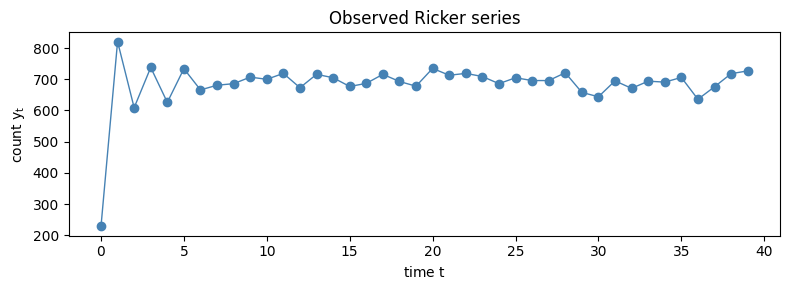

In [3]:
true_params = jnp.log(jnp.array([1.8, 70.0, 10.0]))
y_obs = ricker.generate_data(true_params, 1, key=jax.random.PRNGKey(0))[0]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), np.asarray(y_obs), 'o-', color='steelblue', lw=1)
ax.set(xlabel='time $t$', ylabel='count $y_t$', title='Observed Ricker series')
plt.tight_layout(); plt.show()

### A loose log-space prior

We center the prior in the right ballpark but deliberately off the truth, with moderate scale, so MCMC has real work to do.

In [4]:
prior = MultivariateNormal(
    loc=jnp.log(jnp.array([1.5, 60.0, 8.0])),
    cov=jnp.diag(jnp.array([0.4, 0.3, 0.3]) ** 2),
)

## 2. MCMC via `condition_on`

Because we can write down a closed-form likelihood, the natural inference engine is MCMC. We package the prior and the likelihood in a `SimpleModel` and call `condition_on`. The model satisfies `SupportsLogProb`, so the inference registry auto-selects NUTS — exactly as in the Getting Started tutorial.

In [5]:
model_mcmc = SimpleModel(prior, ricker, name='ricker_mcmc')

posterior_mcmc = condition_on(
    model_mcmc, y_obs,
    num_results=2000, num_warmup=1000, num_chains=2, random_seed=0,
)
print(f'Algorithm: {posterior_mcmc.algorithm}')

Algorithm: tfp_nuts


In [6]:
PARAM_NAMES = ['r', 'K', 'phi']

def summarize(posterior, label):
    nat = np.exp(np.asarray(posterior.draws()).reshape(-1, 3))
    stats = '  '.join(
        f'{n}={nat[:,i].mean():5.2f}\u00b1{nat[:,i].std():4.2f}'
        for i, n in enumerate(PARAM_NAMES)
    )
    print(f'{label:<22}  {stats}')
    return nat


print('truth                  r= 1.80\u00b10.00  K=70.00\u00b10.00  phi=10.00\u00b10.00')
print('-' * 60)
nat_mcmc = summarize(posterior_mcmc, 'NUTS (closed-form)')

truth                  r= 1.80±0.00  K=70.00±0.00  phi=10.00±0.00
------------------------------------------------------------
NUTS (closed-form)      r= 1.81±0.03  K=77.85±6.55  phi= 8.98±0.76


## 3. What changes if you only have a simulator?

The Poisson-Ricker model above has a tractable likelihood because the dynamics are deterministic. Real ecological models almost never are — process noise, demographic stochasticity, individual-based simulators, or chaotic regimes ($r \gtrsim 2.5$ for Ricker) all destroy the closed-form likelihood. In those settings the *only* thing the user can supply is a simulator.

The point here is **not** that NUTS stops working on our toy Ricker — it doesn't. It's that ProbPipe lets you switch to simulator-only inference **without changing the model class or the call site**:

```python
model_sim = SimpleGenerativeModel(prior, ricker)
posterior = condition_on(model_sim, y_obs, ...)
```

`SimpleGenerativeModel` only requires `generate_data`, never `log_likelihood`. Below we walk through three SBI engines, all reached through `condition_on`.

In [7]:
model_sim = SimpleGenerativeModel(prior, ricker, name='ricker_sim')

### 3a. Amortized neural posterior estimation

`sbi_learn_conditional` trains a neural density estimator (a masked autoregressive flow by default) to approximate $p(\theta \mid y)$ as a function of $y$. It returns a `DirectSamplerSBIModel` that implements `SupportsConditioning`, so `condition_on` calls the trained network directly with no MCMC step.

In [8]:
with silence():
    trained_npe = sbi_learn_conditional(
        prior, ricker,
        method='npe', n_simulations=5_000, n_iter=400,
        batch_size=128, n_samples=2000, random_seed=0,
    )
    posterior_npe = condition_on(trained_npe, y_obs)

nat_npe = summarize(posterior_npe, 'NPE (direct sampler)')

NPE (direct sampler)    r= 1.76±0.16  K=64.86±19.44  phi= 8.90±3.00


### 3b. Emulated likelihood + your favorite MCMC

`sbi_learn_likelihood` trains a neural network to approximate $p(y \mid \theta)$ instead of the posterior. The result is *just* a likelihood, so ProbPipe wraps it as a `SimpleModel(prior, neural_likelihood)` and `condition_on` dispatches through the standard inference registry — meaning you can drive the emulated likelihood with NUTS, HMC, RWMH, nutpie, or any other registered MCMC backend.

`sbi_learn_likelihood` also has a `return_likelihood_only=True` mode that hands you just the `Likelihood` object, ready to combine with a different prior or feed into an `IncrementalConditioner` without re-training.

In [9]:
with silence():
    nle_model = sbi_learn_likelihood(
        prior, ricker,
        method='nle', n_simulations=5_000, n_iter=400,
        batch_size=128, random_seed=0,
    )
    posterior_nle = condition_on(
        nle_model, y_obs,
        method='tfp_nuts',
        num_results=1000, num_warmup=500, num_chains=2, random_seed=0,
    )

nat_nle = summarize(posterior_nle, 'NLE + NUTS')

NLE + NUTS              r= 1.48±0.21  K=92.84±22.95  phi= 8.78±1.43


### 3c. Sequential Monte Carlo ABC

SMC-ABC is a non-amortized, likelihood-free method: it iteratively refines a particle approximation to the posterior using the simulator alone. ProbPipe registers `SbiSMCABCMethod` against `SimpleGenerativeModel`, so calling `condition_on` on `model_sim` with `method='sbijax_smcabc'` runs SMC-ABC. We supply problem-specific summary statistics — mean, standard deviation, lag-1 autocorrelation — since identity summaries don't work in $T = 40$ dimensions.

In [10]:
def ricker_summary(y):
    y = jnp.atleast_2d(y).astype(jnp.float32)
    m, s = y.mean(-1, keepdims=True), y.std(-1, keepdims=True)
    ac1 = jnp.mean((y[:,1:] - m) * (y[:,:-1] - m), -1, keepdims=True) / (s**2 + 1e-6)
    return jnp.concatenate([m, s, ac1], -1)


with silence():
    posterior_abc = condition_on(
        model_sim, y_obs,
        method='sbijax_smcabc', summary_fn=ricker_summary,
        n_rounds=4, n_particles=500, random_seed=0,
    )

nat_abc = summarize(posterior_abc, 'SMC-ABC (likelihood-free)')

SMC-ABC (likelihood-free)  r= 1.39±0.39  K=71.54±16.88  phi= 9.46±2.09


## 4. Comparing the four posteriors

All four runs go through the same `condition_on` entry point, return `ApproximateDistribution` objects, and feed downstream operations (`mean`, `variance`, `sample`, `predictive_check`, ...) identically. The marginal posteriors below show NUTS — the gold standard with a closed-form likelihood — alongside three SBI backends that all concentrate near the truth, with looser tails (they pay the cost of training a neural surrogate or matching summary statistics rather than evaluating the exact log-density).

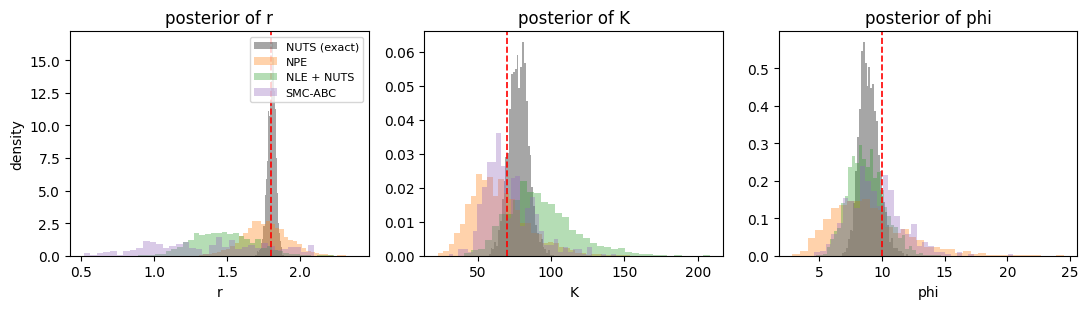

In [11]:
def plot_posteriors(posteriors, colors, truth_nat):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    for j, (ax, name_) in enumerate(zip(axes, PARAM_NAMES)):
        for (label, draws), c in zip(posteriors.items(), colors):
            ax.hist(draws[:, j], bins=35, density=True, alpha=0.35, color=c, label=label)
        ax.axvline(truth_nat[j], color='red', ls='--', lw=1.2)
        ax.set(xlabel=name_, ylabel='density' if j == 0 else None,
               title=f'posterior of {name_}')
    axes[0].legend(fontsize=8, loc='upper right')
    plt.tight_layout(); plt.show()


truth_nat = np.exp(np.asarray(true_params))
plot_posteriors(
    {'NUTS (exact)': nat_mcmc, 'NPE': nat_npe, 'NLE + NUTS': nat_nle, 'SMC-ABC': nat_abc},
    ['black', 'tab:orange', 'tab:green', 'tab:purple'],
    truth_nat,
)

## 5. Flip the switch: stochastic Ricker

Setting `sigma_p > 0` on the *same class* adds Gaussian process noise to the log-growth rate, so each time step has a fresh shock:

$$N_{t+1} = N_t \exp\!\left(r (1 - N_t/K) + \epsilon_t\right), \qquad \epsilon_t \sim \mathcal{N}(0, \sigma_p^2).$$

Now $N_{1:T}$ is a latent stochastic process. The integral $p(y \mid \theta) = \int p(y \mid N_{1:T}) \, p(N_{1:T} \mid \theta) \, dN_{1:T}$ has no closed form, and the Poisson `log_likelihood` we used in §2 would silently return the wrong answer (it treats the noisy trajectory as if it were deterministic). We added an `assert sigma_p == 0` on `log_likelihood` to make that a loud failure rather than a quiet bias.

What *doesn't* change: the simulator. `generate_data` handles both regimes in the same code path, so we can keep reusing the same class, the same prior, and the same `condition_on` call site — all that changes is that we must now wrap the model with `SimpleGenerativeModel` instead of `SimpleModel`, because there is no valid log-density to hand to MCMC.

log_likelihood refused:  closed-form likelihood only valid for sigma_p=0


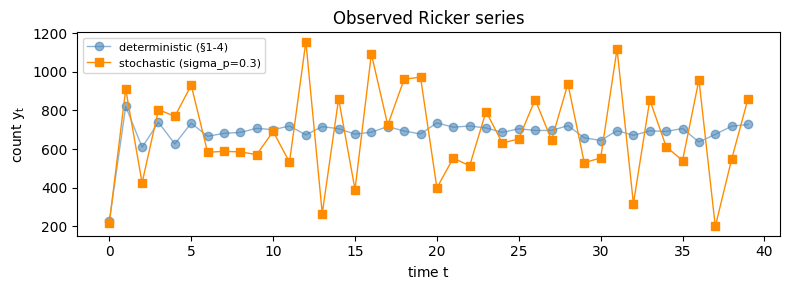

In [12]:
stoch_ricker = RickerObservationModel(T=T, N0=N0, sigma_p=0.3)

# Generate a fresh observed series from the stochastic model.
y_obs_stoch = stoch_ricker.generate_data(
    true_params, 1, key=jax.random.PRNGKey(7),
)[0]

# Protocol check: still a GenerativeLikelihood; log_likelihood now errors on use.
assert isinstance(stoch_ricker, GenerativeLikelihood)
try:
    stoch_ricker.log_likelihood(true_params, y_obs_stoch)
except AssertionError as e:
    print(f'log_likelihood refused:  {e}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), np.asarray(y_obs), 'o-', color='steelblue',
        lw=1, alpha=0.6, label='deterministic (§1-4)')
ax.plot(np.arange(T), np.asarray(y_obs_stoch), 's-', color='darkorange',
        lw=1, label='stochastic (sigma_p=0.3)')
ax.set(xlabel='time $t$', ylabel='count $y_t$', title='Observed Ricker series')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fit the stochastic model — only SBI is available

With no valid log-density we can't use `SimpleModel` + NUTS. We wrap the same class in `SimpleGenerativeModel` and run two SBI engines via `condition_on`: amortized NPE and SMC-ABC. The training and sampling code is identical to §3, just pointed at the stochastic model.

In [13]:
model_sim_stoch = SimpleGenerativeModel(prior, stoch_ricker)

with silence():
    trained_npe_stoch = sbi_learn_conditional(
        prior, stoch_ricker,
        method='npe', n_simulations=5_000, n_iter=400,
        batch_size=128, n_samples=2000, random_seed=1,
    )
    posterior_npe_stoch = condition_on(trained_npe_stoch, y_obs_stoch)

nat_npe_stoch = summarize(posterior_npe_stoch, 'NPE (stochastic)')

with silence():
    posterior_abc_stoch = condition_on(
        model_sim_stoch, y_obs_stoch,
        method='sbijax_smcabc', summary_fn=ricker_summary,
        n_rounds=4, n_particles=500, random_seed=1,
    )

nat_abc_stoch = summarize(posterior_abc_stoch, 'SMC-ABC (stochastic)')

NPE (stochastic)        r= 1.53±0.30  K=63.82±19.95  phi= 8.56±2.70


SMC-ABC (stochastic)    r= 1.38±0.35  K=71.94±16.24  phi= 9.88±2.00


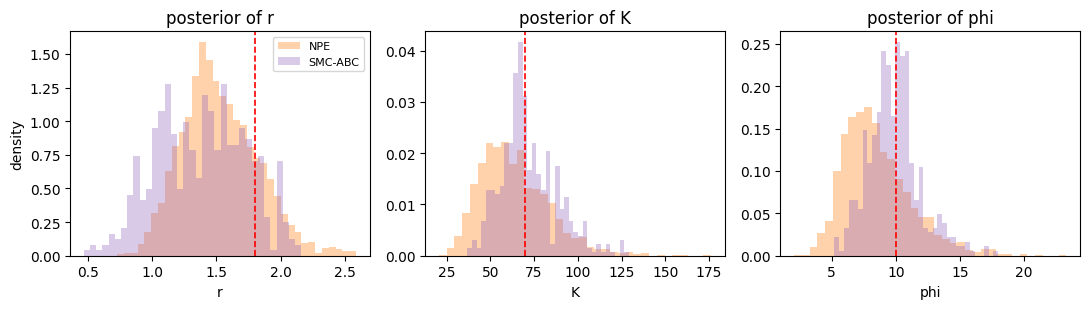

In [14]:
plot_posteriors(
    {'NPE': nat_npe_stoch, 'SMC-ABC': nat_abc_stoch},
    ['tab:orange', 'tab:purple'],
    truth_nat,
)

## 6. The unifying picture: protocol-based dispatch

Every cell that fitted a posterior in this tutorial called the same function, `condition_on(model, data, ...)`. The decision of *which* engine to run was made by inspecting the model:

| Model class | Protocols satisfied | What `condition_on` dispatches to |
|---|---|---|
| `SimpleModel(prior, ricker)` | `SupportsLogProb` | NUTS / HMC / RWMH / nutpie / ... — picked by the inference registry from the model type |
| `DirectSamplerSBIModel` (returned by `sbi_learn_conditional`) | `SupportsConditioning` | Direct call into the trained network — no registry lookup |
| `SimpleModel(prior, neural_likelihood)` (returned by `sbi_learn_likelihood`) | `SupportsLogProb` | Any registered MCMC backend, selected automatically or via `method=` |
| `SimpleGenerativeModel(prior, ricker)` | only `SupportsSampling` on the prior | `SbiSMCABCMethod` (registered under that model type) |

This is the payoff of ProbPipe's protocol-driven design. The model code never mentions an inference algorithm. Switching from NUTS to NPE to NLE-plus-NUTS to SMC-ABC is *one keyword argument* (or no argument at all — the registry picks for you). §5 showed the flip from tractable to intractable regime is literally a single constructor argument: `sigma_p=0.3` and `SimpleGenerativeModel` instead of `SimpleModel`. The rest of the workflow carries over unchanged. Posteriors from all routes are interchangeable downstream — the same `mean`, `variance`, predictive checks, uncertainty propagation, and provenance tracking apply.

### References

- Ricker, W.E. (1954). Stock and recruitment. *Journal of the Fisheries Research Board of Canada*, 11(5), 559–623.
- Wood, S.N. (2010). [Statistical inference for noisy nonlinear ecological dynamic systems](https://doi.org/10.1038/nature09319). *Nature*, 466, 1102–1104.
- Cranmer, K., Brehmer, J. & Louppe, G. (2020). [The frontier of simulation-based inference](https://doi.org/10.1073/pnas.1912789117). *PNAS*, 117(48), 30055–30062.
- Papamakarios, G. & Murray, I. (2016). [Fast ε-free inference of simulation models with Bayesian conditional density estimation](https://papers.nips.cc/paper/6084). *NeurIPS 2016*.
- Sisson, S.A., Fan, Y. & Beaumont, M.A. (2007). [Sequential Monte Carlo without likelihoods](https://doi.org/10.1073/pnas.0607208104). *PNAS*, 104(6), 1760–1765.

## Next steps

- [**API Reference**](../api/inference.md) — full list of registered inference methods, model wrappers, and the `condition_on` operation.
- [**Reference Notebooks**](../reference_notebooks.md) — focused examples for individual features.